# SVM Model for Medical Specialty Classification
This notebook trains and evaluates two Support Vector Machine (SVM) models to classify medical specialties from clinical notes, using a dataset of around 5000 records.

To properly prevent **underfitting** and **overfitting**:
1. We use a **Train-Test Split**: A hold-out test set is kept entirely unseen during training.
2. We use **GridSearchCV with Cross-Validation**: We train the models across multiple hyperparameter values (`C`, `kernel`) with K-fold cross-validation on the training set to find the best configuration that generalizes well without overfitting to the training data.

We compare two feature sets:
1. **Model 1**: Uses only the `transcription` feature.
2. **Model 2**: Uses a combination of `transcription`, `keywords`, and `extracted_features`.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [16]:
# Load dataset
df = pd.read_csv("processed_clinical_data.csv")
print(f"Original dataset shape: {df.shape}")

# Handle missing values in text columns
text_cols = ['transcription', 'keywords', 'extracted_features']
for col in text_cols:
    df[col] = df[col].fillna('')

# Create Model 1 feature (basic)
df['text_basic'] = df['transcription']

# Create Model 2 feature (combined)
df['text_combined'] = df['transcription'] + " " + df['keywords'] + " " + df['extracted_features']

# Drop rows where target might be null
df = df.dropna(subset=['medical_specialty'])
print(f"Processed dataset shape: {df.shape}")

df.head()


Original dataset shape: (4966, 7)
Processed dataset shape: (4966, 9)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords,extracted_features,text_basic,text_combined
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...","['C0043210', 'C3864418', 'C4526594', 'C1280519']","SUBJECTIVE:, This 23-year-old white female pr...","SUBJECTIVE:, This 23-year-old white female pr..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...","['C0262926', 'C0239067', 'C0036988', 'public s...","PAST MEDICAL HISTORY:, He has difficulty climb...","PAST MEDICAL HISTORY:, He has difficulty climb..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...","['C0262512', 'C2987187', 'C1262477', 'C0015259...","HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...","['C1705052', 'C0238705', 'C1182755', 'cm.,2. N...","2-D M-MODE: , ,1. Left atrial enlargement wit...","2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...","['C0455830', 'C0677535', 'C1980023', 'C0080310...",1. The left ventricular cavity size and wall ...,1. The left ventricular cavity size and wall ...


In [17]:
# Define features and target
X_basic = df['text_basic']
X_combined = df['text_combined']
y = df['medical_specialty']

# Split for Model 1 (80% train, 20% test)
# Note: stratify=y is omitted to avoid errors with extremely rare classes
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_basic, y, test_size=0.2, random_state=42
)

# Split for Model 2 (Using exactly the same indices)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train_b.shape[0]}")
print(f"Testing samples: {X_test_b.shape[0]}")


Training samples: 3972
Testing samples: 994


In [18]:
# --- MODEL 1: Basic Features (transcription only) ---

pipeline_b = Pipeline([
    # ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)),
    ('svm', SVC(random_state=42))
])

# Define parameter grid for Grid Search
# Searching different combinations of C and kernels
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

# GridSearchCV will handle 3-fold cross validation on the training data
grid_b = GridSearchCV(pipeline_b, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

print("Training Model 1 (Basic Text) with GridSearchCV...")
grid_b.fit(X_train_b, y_train_b)

print(f"\nBest Parameters for Model 1: {grid_b.best_params_}")
print(f"Best CV Accuracy (Model 1): {grid_b.best_score_:.4f}")


Training Model 1 (Basic Text) with GridSearchCV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Parameters for Model 1: {'svm__C': 0.1, 'svm__kernel': 'linear'}
Best CV Accuracy (Model 1): 0.3228


Classification Report - Model 1 (Basic Text):

                               precision    recall  f1-score   support

         Allergy / Immunology       0.00      0.00      0.00         2
                      Autopsy       0.00      0.00      0.00         1
                   Bariatrics       0.00      0.00      0.00         2
   Cardiovascular / Pulmonary       0.41      0.15      0.22        79
                 Chiropractic       0.00      0.00      0.00         2
   Consult - History and Phy.       0.29      0.97      0.45       111
   Cosmetic / Plastic Surgery       0.00      0.00      0.00         7
                    Dentistry       0.00      0.00      0.00         8
                  Dermatology       0.00      0.00      0.00         2
         Diets and Nutritions       0.00      0.00      0.00         1
            Discharge Summary       0.00      0.00      0.00        23
         ENT - Otolaryngology       0.00      0.00      0.00        32
       Emergency Room Reports

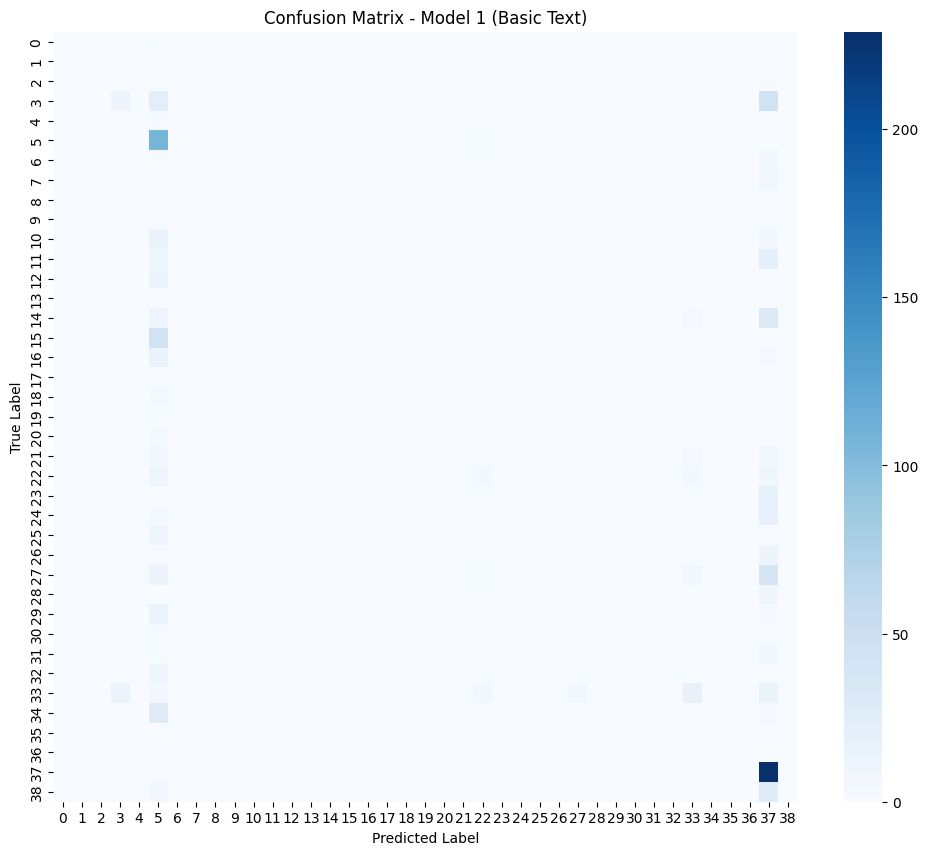

In [19]:
# Evaluate Model 1 on the hold-out test set
y_pred_b = grid_b.predict(X_test_b)

print("Classification Report - Model 1 (Basic Text):\n")
print(classification_report(y_test_b, y_pred_b, zero_division=0))

# Confusion Matrix for Model 1
plt.figure(figsize=(12, 10))
cm_b = confusion_matrix(y_test_b, y_pred_b)
sns.heatmap(cm_b, annot=False, cmap="Blues")
plt.title("Confusion Matrix - Model 1 (Basic Text)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [21]:
# --- MODEL 2: Combined Features (transcription + keywords + extracted_features) ---

pipeline_c = Pipeline([
    # ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=10000, sublinear_tf=True)),
    ('svm', SVC(random_state=42))
])

grid_c = GridSearchCV(pipeline_c, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

print("Training Model 2 (Combined Text) with GridSearchCV...")
grid_c.fit(X_train_c, y_train_c)

print(f"\nBest Parameters for Model 2: {grid_c.best_params_}")
print(f"Best CV Accuracy (Model 2): {grid_c.best_score_:.4f}")


Training Model 2 (Combined Text) with GridSearchCV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Parameters for Model 2: {'svm__C': 10, 'svm__kernel': 'linear'}
Best CV Accuracy (Model 2): 0.4607


Classification Report - Model 2 (Combined Text):

                               precision    recall  f1-score   support

         Allergy / Immunology       0.00      0.00      0.00         2
                      Autopsy       1.00      1.00      1.00         1
                   Bariatrics       0.00      0.00      0.00         2
   Cardiovascular / Pulmonary       0.69      0.67      0.68        79
                 Chiropractic       0.00      0.00      0.00         2
   Consult - History and Phy.       0.30      0.33      0.32       111
   Cosmetic / Plastic Surgery       0.00      0.00      0.00         7
                    Dentistry       0.00      0.00      0.00         8
                  Dermatology       0.00      0.00      0.00         2
         Diets and Nutritions       0.00      0.00      0.00         1
            Discharge Summary       0.50      0.61      0.55        23
         ENT - Otolaryngology       0.95      0.62      0.75        32
       Emergency Room Repo

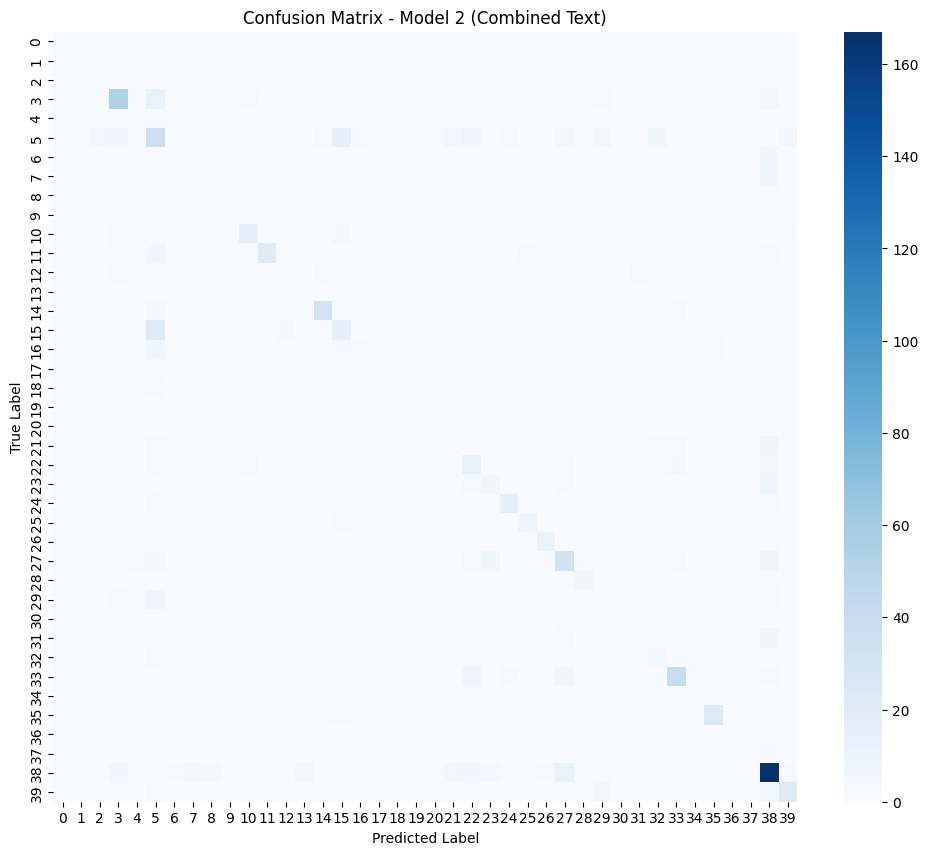

In [22]:
# Evaluate Model 2 on the hold-out test set
y_pred_c = grid_c.predict(X_test_c)

print("Classification Report - Model 2 (Combined Text):\n")
print(classification_report(y_test_c, y_pred_c, zero_division=0))

# Confusion Matrix for Model 2
plt.figure(figsize=(12, 10))
cm_c = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_c, annot=False, cmap="Blues")
plt.title("Confusion Matrix - Model 2 (Combined Text)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [8]:
# Save models to disk
joblib.dump(grid_b.best_estimator_, 'svm_model_basic.pkl')
joblib.dump(grid_c.best_estimator_, 'svm_model_combined.pkl')
print("Models saved successfully to disk (svm_model_basic.pkl, svm_model_combined.pkl).")


Models saved successfully to disk (svm_model_basic.pkl, svm_model_combined.pkl).
